Loan prediction dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


2. Load the Data

In [ ]:
df = pd.read_csv("/content/Loan Prediction.csv")  # Change to your file name


Explore the Data

In [ ]:
print(df.head())


   Id   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  1303834   23           3         single          rented            no   
1   2  7574516   40          10         single          rented            no   
2   3  3991815   66           4        married          rented            no   
3   4  6256451   41           2         single          rented           yes   
4   5  5768871   47          11         single          rented            no   

            Profession                 CITY           STATE  CURRENT_JOB_YRS  \
0  Mechanical_engineer                 Rewa  Madhya_Pradesh                3   
1   Software_Developer             Parbhani     Maharashtra                9   
2     Technical_writer            Alappuzha          Kerala                4   
3   Software_Developer          Bhubaneswar          Odisha                2   
4        Civil_servant  Tiruchirappalli[10]      Tamil_Nadu                3   

   CURRENT_HOUSE_YRS  Risk_Flag  
0   

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB
None


In [ ]:
print(df.isnull().sum())

Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64


Visualize Key Features

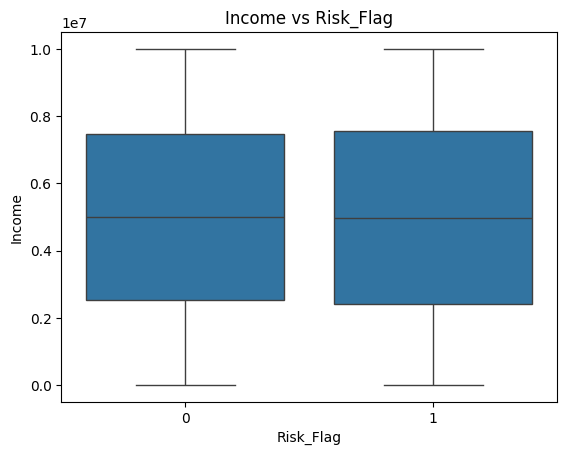

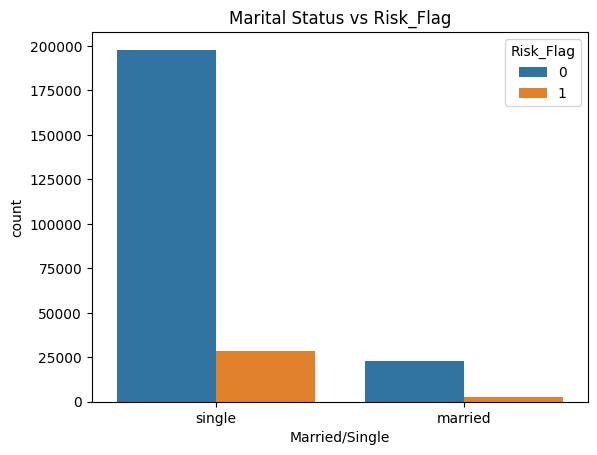

In [ ]:
sns.boxplot(x='Risk_Flag', y='Income', data=df)
plt.title('Income vs Risk_Flag')
plt.show()

sns.countplot(x='Married/Single', hue='Risk_Flag', data=df)
plt.title('Marital Status vs Risk_Flag')
plt.show()


 Encode Categorical Features

In [ ]:
# Label encode simple columns
le = LabelEncoder()
df['Married/Single'] = le.fit_transform(df['Married/Single'])
df['House_Ownership'] = le.fit_transform(df['House_Ownership'])
df['Car_Ownership'] = le.fit_transform(df['Car_Ownership'])

# Optional: drop less useful columns (like City/State)
df = df.drop(['Id', 'CITY', 'STATE', 'Profession'], axis=1)


Prepare Data for Model

In [ ]:
X = df.drop('Risk_Flag', axis=1)
y = df['Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Train Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix (Logistic):\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8759325396825397
Confusion Matrix (Logistic):
 [[44147     0]
 [ 6253     0]]


Train Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8819444444444444
Confusion Matrix (Decision Tree):
 [[40892  3255]
 [ 2695  3558]]
